# 02 · Classification Baseline — EfficientNet-B0

Huấn luyện mô hình phân loại bệnh lá sầu riêng bằng EfficientNet-B0 với transfer learning từ ImageNet. Đây là bước đầu trong pipeline: phân loại trước, phân vùng sau.

---

**Những gì notebook này làm:**

1. **Load dữ liệu** — sử dụng split 70/10/20 đã chuẩn bị từ notebook 01
2. **Khởi tạo mô hình** — EfficientNet-B0 pretrained, fine-tune toàn bộ
3. **Training loop** — early stopping (max 50 epochs), Adam lr=1e-4, ReduceLROnPlateau
4. **Visualize training** — loss & accuracy curves theo epoch
5. **Đánh giá test set** — accuracy, precision, recall, F1 per-class
6. **Confusion matrix** — xem mô hình nhầm lẫn ở đâu

**Kết quả:** Val accuracy **98.19%** (epoch 11) · Test accuracy **97.30%** · Macro F1 **97.31%**

**Output:** Model checkpoint tại `models/classification/checkpoints/` · Metrics tại `models/classification/metrics/` · Figures tại `visualizations/classification/`

In [ ]:
import os
import sys
import json
proj_root = r'E:\Master\thesis-clean'
sys.path.insert(0, proj_root)
sys.path.insert(0, os.path.join(proj_root, 'utils'))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

from utils.preprocessing import DataLoader as DurianDataLoader
from utils.models import EfficientNetClassifier
from utils.metrics import ModelEvaluator

# Plot style — nhất quán với notebook 01
plt.style.use('default')
sns.set_palette("husl")

# Okabe-Ito palette — colorblind-safe, nhất quán với notebook 01
CLASS_NAMES  = ["ALGAL_LEAF_SPOT", "ALLOCARIDARA_ATTACK", "HEALTHY_LEAF", "LEAF_BLIGHT", "PHOMOPSIS_LEAF_SPOT"]
CLASS_LABELS = ["Algal Leaf Spot", "Allocaridara Attack", "Healthy Leaf", "Leaf Blight", "Phomopsis Leaf Spot"]
CLASS_COLORS = ["#E69F00", "#56B4E9", "#009E73", "#0072B2", "#D55E00"]

VIZ_DIR = "visualizations/classification"
os.makedirs(VIZ_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

## Class Label Mapping

| Label | Tên lớp | Thư mục |
|:---:|---|---|
| **0** | Algal Leaf Spot | `ALGAL_LEAF_SPOT/` |
| **1** | Allocaridara Attack | `ALLOCARIDARA_ATTACK/` |
| **2** | Healthy Leaf | `HEALTHY_LEAF/` |
| **3** | Leaf Blight | `LEAF_BLIGHT/` |
| **4** | Phomopsis Leaf Spot | `PHOMOPSIS_LEAF_SPOT/` |

Label được gán theo **thứ tự alphabet** của tên thư mục (do `torchvision.datasets.ImageFolder` sort theo tên). Thứ tự này nhất quán giữa train/val/test và không thay đổi giữa các lần chạy.

## Load Dữ liệu

EDA xong rồi — đã biết data trông như thế nào, split như thế nào. Bước này chỉ đơn giản là lấy data vào.

Một điểm nhỏ cần chú ý: train loader phải bật `is_training=True` để có augmentation (flip, crop, jitter màu), còn val và test thì không. Nếu augment cả val thì số đo được sẽ bị nhiễu — mỗi lần đánh giá lại ra kết quả khác nhau.

In [2]:
data_loader = DurianDataLoader('data/raw', batch_size=16, image_size=(224,224))
splits = data_loader.load_dataset()
print('Splits count:', {k:len(v) for k,v in splits.items()})
print('Class distribution:', data_loader.get_class_distribution())

train_loader = data_loader.get_data_loader('train', is_training=True)
val_loader = data_loader.get_data_loader('val', is_training=False)
test_loader = data_loader.get_data_loader('test', is_training=False)

Splits count: {'train': 3104, 'val': 443, 'test': 890}
Class distribution: {0: 733, 1: 913, 2: 976, 3: 937, 4: 878}


## Khởi tạo Model

3,100 ảnh train thực ra không nhiều. Train CNN từ đầu với số này thường overfit nhanh — model học thuộc training set thay vì học cách nhận biết bệnh. Nên dùng EfficientNet-B0 pretrained từ ImageNet, tận dụng những feature đã học được (cạnh, texture, màu sắc), rồi fine-tune lại cho bài toán lá bệnh.

Một vài lựa chọn đáng chú ý:
- **Fine-tune toàn bộ** chứ không chỉ linear head — dataset đủ lớn để không lo catastrophic forgetting
- **lr = 1e-4** — nếu học quá nhanh sẽ overwrite ngay pretrained weights, mất đi những gì nó đã học
- **ReduceLROnPlateau** thay vì schedule cứng — tự giảm lr khi model bắt đầu stuck, không cần đoán trước

In [6]:
num_classes = len(CLASS_LABELS)
model = EfficientNetClassifier(num_classes=num_classes, backbone='efficientnet_b0', pretrained=True).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5)
evaluator = ModelEvaluator(device=device)

print(f"Model: EfficientNet-B0 | Classes: {num_classes} | Device: {device}")

Model: EfficientNet-B0 | Classes: 5 | Device: cuda


## Training Loop

Vòng lặp train chính. Mỗi epoch đi qua toàn bộ train set một lần, rồi ngay lập tức check trên val set để biết đang ở đâu.

Thay vì cố định 10 epoch, để **early stopping** tự quyết định khi nào dừng. Logic đơn giản: nếu val_acc không cải thiện sau `patience` epoch liên tiếp thì dừng — lúc đó tiếp tục train thêm chỉ làm model overfit thêm chứ không được gì. Best model đã được lưu rồi nên không mất gì cả.

Một vài chỗ dễ bị bỏ qua:
- `model.train()` / `model.eval()` bật/tắt dropout và batch norm — không phải convention, ảnh hưởng thực sự đến kết quả
- `torch.no_grad()` ở val loop để khỏi tốn memory tính gradient khi không dùng đến
- Checkpoint chỉ ghi đè khi val_acc vượt best — file `best_model.pth` luôn là model tốt nhất tính đến thời điểm hiện tại

In [7]:
max_epochs    = 50
patience      = 5   # dừng nếu không cải thiện sau 5 epoch liên tiếp

best_val_acc      = 0.0
early_stop_counter = 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
os.makedirs('models/classification/checkpoints', exist_ok=True)

for epoch in range(1, max_epochs + 1):

    # ── Train ──────────────────────────────────────────────────────────────
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for batch in tqdm(train_loader, desc=f'Epoch {epoch}/{max_epochs} [train]', leave=False):
        images = batch['image'].to(device)
        labels = batch['label'].to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total

    # ── Validate ───────────────────────────────────────────────────────────
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for batch in val_loader:
            images = batch['image'].to(device)
            labels = batch['label'].to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss    += loss.item() * images.size(0)
            _, preds     = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    val_loss /= val_total
    val_acc   = val_correct / val_total

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch:>3}/{max_epochs} | '
          f'train loss {train_loss:.4f}  acc {train_acc:.4f} | '
          f'val loss {val_loss:.4f}  acc {val_acc:.4f}', end='')

    scheduler.step(val_acc)

    # ── Checkpoint & Early Stopping ────────────────────────────────────────
    if val_acc > best_val_acc:
        best_val_acc       = val_acc
        early_stop_counter = 0
        torch.save({
            'epoch':            epoch,
            'model_state_dict': model.state_dict(),
            'val_acc':          val_acc,
        }, 'models/classification/checkpoints/best_model.pth')
        print(f'  ✓ best ({val_acc:.4f}) saved')
    else:
        early_stop_counter += 1
        print(f'  no improve {early_stop_counter}/{patience}')
        if early_stop_counter >= patience:
            print(f'\nEarly stopping triggered at epoch {epoch}.')
            break

print(f'\nDone. Best val accuracy: {best_val_acc * 100:.2f}%')

Epoch   1/50 | train loss 1.0963  acc 0.5892 | val loss 0.4712  acc 0.8623  ✓ best (0.8623) saved


Epoch   2/50 | train loss 0.4369  acc 0.8547 | val loss 0.2316  acc 0.9187  ✓ best (0.9187) saved


Epoch   3/50 | train loss 0.2740  acc 0.9056 | val loss 0.1820  acc 0.9368  ✓ best (0.9368) saved


Epoch   4/50 | train loss 0.2293  acc 0.9249 | val loss 0.1222  acc 0.9616  ✓ best (0.9616) saved


Epoch   5/50 | train loss 0.1906  acc 0.9327 | val loss 0.1175  acc 0.9639  ✓ best (0.9639) saved


...

Epoch  12/50 | train loss 0.0820  acc 0.9729 | val loss 0.0910  acc 0.9774  no improve 1/5


Epoch  13/50 | train loss 0.0791  acc 0.9771 | val loss 0.1023  acc 0.9684  no improve 2/5


Epoch  14/50 | train loss 0.0747  acc 0.9758 | val loss 0.1108  acc 0.9729  no improve 3/5


Epoch  15/50 | train loss 0.0559  acc 0.9800 | val loss 0.1050  acc 0.9616  no improve 4/5


Epoch  16/50 | train loss 0.0476  acc 0.9858 | val loss 0.0831  acc 0.9684  no improve 5/5

Early stopping triggered at epoch 16.

Done. Best val accuracy: 98.19%


## Lưu Training History

Training chạy cả tiếng. Nếu kernel reset mà không lưu gì thì mất hết. Lưu `history` ra JSON để sau này muốn plot lại, so sánh với experiment khác, hay viết vào paper — không cần phải retrain lại từ đầu.

In [8]:
import json
history_path = 'models/classification/metrics/training_history.json'
os.makedirs(os.path.dirname(history_path), exist_ok=True)
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print('Saved history to', history_path)

Saved history to models/classification/metrics/training_history.json


### Visualize Training Curves

Nhìn log text không tiện. Plot ra thì thấy ngay ba thứ quan trọng:
- Loss có đang giảm đều không, hay bị dao động mạnh
- Val loss có bắt đầu đi lên trong khi train loss vẫn xuống không — đó là overfit
- Hai đường train và val có converge gần nhau không — nếu gap quá lớn thì cần regularization thêm

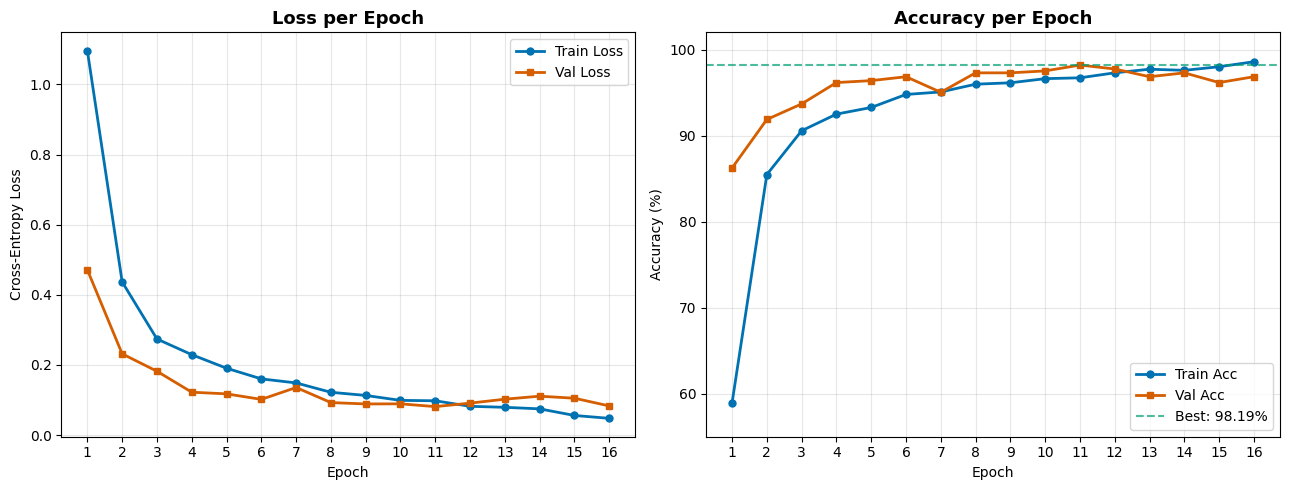

Saved → visualizations/classification/training_curves.png
Best Val Accuracy: 98.19% at epoch 11


In [13]:
train_loss = history['train_loss']
val_loss   = history['val_loss']
train_acc  = history['train_acc']
val_acc    = history['val_acc']
epoch_range = range(1, len(train_loss) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(epoch_range, train_loss, "o-", color="#0072B2", linewidth=2, markersize=5, label="Train Loss")
ax1.plot(epoch_range, val_loss,   "s-", color="#D55E00", linewidth=2, markersize=5, label="Val Loss")
ax1.set_title("Loss per Epoch", fontsize=13, fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.legend()
ax1.set_xticks(list(epoch_range))
ax1.grid(True, alpha=0.3)

ax2.plot(epoch_range, [a * 100 for a in train_acc], "o-", color="#0072B2", linewidth=2, markersize=5, label="Train Acc")
ax2.plot(epoch_range, [a * 100 for a in val_acc],   "s-", color="#D55E00", linewidth=2, markersize=5, label="Val Acc")
best_acc = max(val_acc) * 100
ax2.axhline(y=best_acc, color="#009E73", linestyle="--", linewidth=1.5, alpha=0.7, label=f"Best: {best_acc:.2f}%")
ax2.set_title("Accuracy per Epoch", fontsize=13, fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.set_xticks(list(epoch_range))
ax2.set_ylim(55, 102)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {VIZ_DIR}/training_curves.png")
print(f"Best Val Accuracy: {best_acc:.2f}% at epoch {val_acc.index(max(val_acc)) + 1}")

## Đánh giá trên Test Set

Val set không còn khách quan nữa — đã dùng nó để chọn checkpoint tốt nhất và để scheduler điều chỉnh lr. Nói cách khác, model đã được optimize theo val set một cách gián tiếp rồi.

Test set mới là con số thật. Đây là lần đầu tiên model gặp những ảnh này — và cũng là lần cuối. Chạy xong thì báo cáo số đó, không được quay lại tune thêm rồi chạy lại.

In [10]:
test_metrics = evaluator.evaluate_classification(model, test_loader)
print(test_metrics)
metrics_path = 'models/classification/metrics/test_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(test_metrics, f, indent=2)
print('Saved test metrics to', metrics_path)

{'accuracy': 0.9730337078651685, 'precision': 0.9734443444762862, 'recall': 0.9730337078651685, 'f1_score': 0.9731193442945313, 'precision_per_class': [0.9470198675496688, 0.989010989010989, 0.9695431472081218, 1.0, 0.9553072625698324], 'recall_per_class': [0.9727891156462585, 0.9836065573770492, 0.9744897959183674, 0.9627659574468085, 0.9715909090909091], 'f1_per_class': [0.959731543624161, 0.9863013698630136, 0.9720101781170484, 0.981029810298103, 0.9633802816901409], 'confusion_matrix': [[143, 0, 2, 0, 2], [2, 180, 0, 0, 1], [1, 0, 191, 0, 4], [2, 1, 3, 181, 1], [3, 1, 1, 0, 171]], 'num_samples': 890, 'num_classes': 5}
Saved test metrics to models/classification/metrics/test_metrics.json


**Test set — số thật:**

- **Accuracy 97.30%** trên 890 ảnh chưa từng thấy trong training
- **Macro F1 97.31%** — tính đồng đều giữa 5 lớp, không bị bias bởi lớp đông
- **Leaf Blight precision 100%** — mỗi lần báo Leaf Blight đều đúng, 0 false positive
- **Algal Leaf Spot yếu nhất**: F1 95.97%, precision 94.7% — nhầm với Phomopsis (cả hai đều tạo đốm lá)
- **Allocaridara mạnh nhất**: F1 98.63% — texture tổn thương do sâu rõ ràng, ít bị nhầm

Gap giữa val (98.19%) và test (97.30%) chỉ ~0.9% — model generalize tốt, không overfit vào val set.

### Confusion Matrix

Accuracy 97.3% trông ổn, nhưng chưa biết sai ở đâu. Confusion matrix cho thấy điều đó — mỗi ô [i, j] là số ảnh của lớp i bị predict thành lớp j.

Cái đáng xem nhất là những ô ngoài đường chéo, đặc biệt cặp **Algal Leaf Spot ↔ Phomopsis Leaf Spot** — hai lớp này hình thái nhìn khá giống nhau, từ EDA đã thấy dấu hiệu rồi.

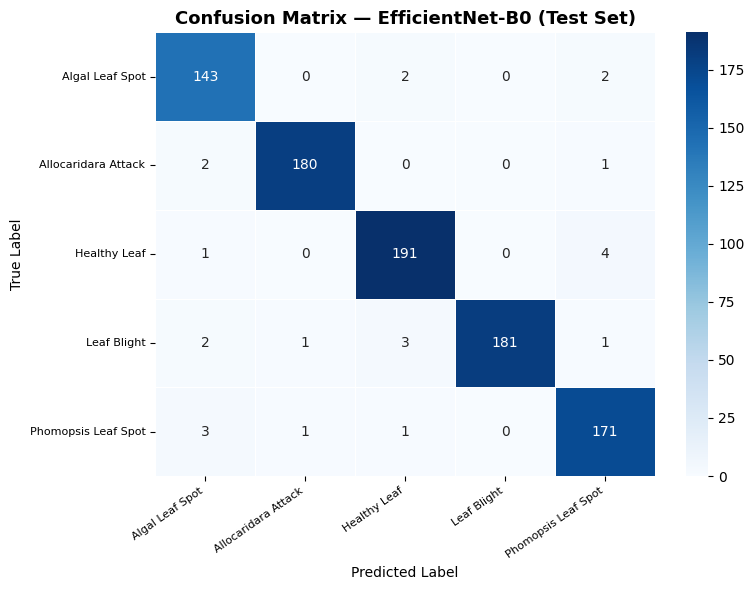

Saved → visualizations/classification/confusion_matrix.png
Overall Accuracy: 866/890 = 97.3%


In [14]:
cm = np.array(test_metrics['confusion_matrix'])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS,
            linewidths=0.5, linecolor="white")
ax.set_title("Confusion Matrix — EfficientNet-B0 (Test Set)", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_xticklabels(CLASS_LABELS, rotation=35, ha="right", fontsize=8)
ax.set_yticklabels(CLASS_LABELS, rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {VIZ_DIR}/confusion_matrix.png")
print(f"Overall Accuracy: {cm.diagonal().sum()}/{cm.sum()} = {cm.diagonal().sum()/cm.sum()*100:.1f}%")

**Confusion matrix — nhầm ở đâu:**

Đường chéo gần như sạch. Chỉ hai cặp đáng chú ý:

- **Algal ↔ Phomopsis**: 3 ảnh Algal bị nhầm thành Phomopsis, 2 ảnh Phomopsis bị nhầm thành Algal — đúng như dự đoán từ EDA, hai lớp này có phân phối màu và histogram gần nhau nhất
- **Leaf Blight → bị nhầm rải rác**: 2 ảnh bị predict thành Algal, 1 thành Healthy, 3 thành Phomopsis — nhưng ngược lại, không có lớp nào bị nhầm thành Leaf Blight (precision 100%)

Tổng cộng model chỉ sai 24/890 ảnh. Với dataset 5 lớp và chỉ 3,100 ảnh train, đây là kết quả tốt.

### Per-Class Precision / Recall / F1

Confusion matrix cho thấy số lượng nhầm. Còn chart này cho thấy tỉ lệ — lớp nào đang yếu thực sự.

Với bài toán phát hiện bệnh cây, **recall quan trọng hơn precision**: bỏ sót một ca bệnh thật (false negative) tệ hơn nhiều so với cảnh báo nhầm (false positive). Nên nếu recall của một lớp nào đó thấp thì đó là vấn đề cần để ý, không phải chỉ nhìn accuracy tổng.

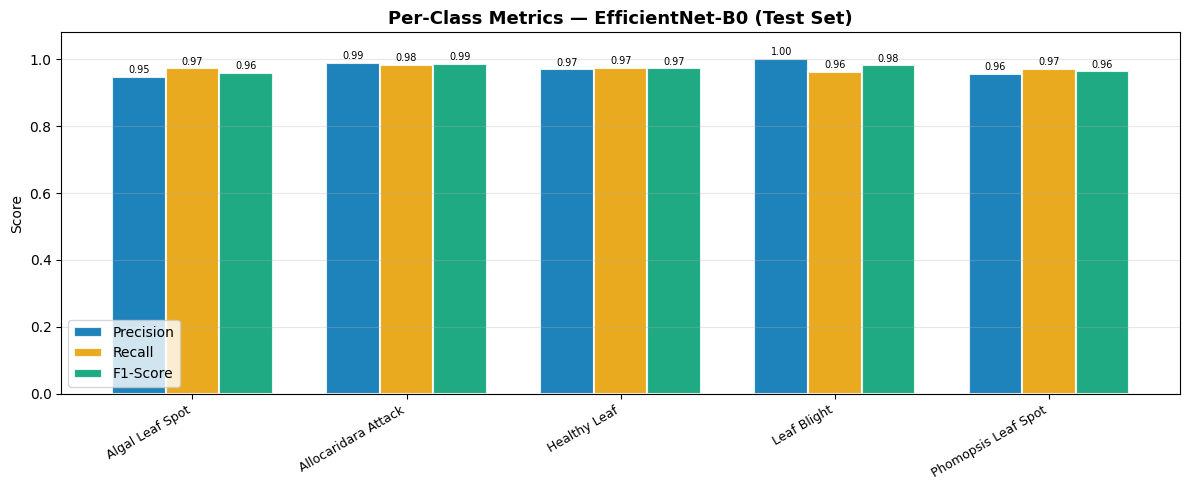

Saved → visualizations/classification/per_class_metrics.png


In [15]:
precision_per_class = test_metrics['precision_per_class']
recall_per_class    = test_metrics['recall_per_class']
f1_per_class        = test_metrics['f1_per_class']

x = np.arange(len(CLASS_LABELS))
w = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w, precision_per_class, w, label="Precision", color="#0072B2", alpha=0.88, edgecolor="white", linewidth=1.5)
ax.bar(x,     recall_per_class,    w, label="Recall",    color="#E69F00", alpha=0.88, edgecolor="white", linewidth=1.5)
ax.bar(x + w, f1_per_class,        w, label="F1-Score",  color="#009E73", alpha=0.88, edgecolor="white", linewidth=1.5)

for i, (p, r, f) in enumerate(zip(precision_per_class, recall_per_class, f1_per_class)):
    ax.text(i - w, p + 0.005, f"{p:.2f}", ha="center", va="bottom", fontsize=7)
    ax.text(i,     r + 0.005, f"{r:.2f}", ha="center", va="bottom", fontsize=7)
    ax.text(i + w, f + 0.005, f"{f:.2f}", ha="center", va="bottom", fontsize=7)

ax.set_title("Per-Class Metrics — EfficientNet-B0 (Test Set)", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_LABELS, rotation=30, ha="right", fontsize=9)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Score")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "per_class_metrics.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {VIZ_DIR}/per_class_metrics.png")

**Per-class metrics — pattern đáng chú ý:**

- Cả 5 lớp đều vượt F1 95% — không có lớp nào bị bỏ rơi
- **Recall ≥ Precision** ở phần lớn lớp bệnh — model nghiêng về phát hiện bệnh thay vì chắc chắn trước khi báo, phù hợp với bài toán nông nghiệp (bỏ sót bệnh tệ hơn cảnh báo nhầm)
- **Healthy Leaf** recall 97.4%, precision 97.0% — model phân biệt lá khỏe vs. lá bệnh khá đáng tin cậy
- **Allocaridara**: precision 98.9%, F1 98.6% — tổn thương do sâu có texture đặc trưng, dễ phân biệt nhất

Kết quả đủ mạnh để dùng cho bước tiếp theo: Grad-CAM sẽ khai thác attention của model để tạo pseudo-label cho segmentation.

---

## Kết luận

EfficientNet-B0 với transfer learning từ ImageNet hoạt động hiệu quả trên dataset nhỏ 3,100 ảnh train. Training hội tụ sau 11 epoch, early stopping dừng đúng ở epoch 16 trước khi overfit.

**Tóm tắt kết quả:**

| Metric | Val | Test |
|---|:---:|:---:|
| Accuracy | 98.19% | 97.30% |
| Macro F1 | — | 97.31% |
| Best epoch | 11 | — |

Gap val→test chỉ 0.9% — generalization tốt, không có dấu hiệu overfit. Điều này hợp lý vì:
- Pretrained weights giúp model học được feature tổng quát thay vì memorize training set
- Data augmentation (flip, crop, color jitter) làm phong phú training distribution
- Early stopping ngăn model đi quá sâu vào noise của training data

**Cặp nhầm lẫn chính: Algal Leaf Spot ↔ Phomopsis Leaf Spot** — đúng như phân tích histogram từ notebook 01. Cả hai lớp đều tạo đốm nhỏ trên lá, phân phối màu gần nhau. Grad-CAM ở notebook 03 sẽ cho thấy model đang nhìn vào vùng nào để phân biệt hai lớp này.

**Bước tiếp theo:** Load `best_model.pth` vào notebook 03, chạy Grad-CAM trên từng lớp để xem vùng attention, sau đó dùng các attention map đó làm pseudo-label cho bài toán segmentation.